# 01 — Exploratory Data Analysis
### Commodity Volatility Forecasting System

**Purpose:** Understand the data before touching features or models.
Every section answers a specific question that affects a downstream decision.

| # | Question | Why it matters |
|---|----------|---------------|
| 1 | Is the data complete? | Gaps and nulls silently corrupt rolling windows |
| 2 | What do price series look like? | Identify regimes, structural breaks, data errors |
| 3 | Are returns fat-tailed? | Validates GARCH as the right baseline |
| 4 | Is volatility clustered? | The core assumption GARCH is built on |
| 5 | Are returns stationary? | Non-stationary returns break most models |
| 6 | How correlated are commodities? | Justifies (or kills) cross-commodity features |
| 7 | Do macro variables relate to volatility? | Justifies DXY / treasury features |
| 8 | Any data quality red flags? | Catch problems before they corrupt features |


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SILVER = Path("../data/silver")
PLOTS  = Path("eda_plots")
PLOTS.mkdir(exist_ok=True)

DATA = pd.read_parquet(SILVER / "aligned.parquet")

COMMODITIES = ["wti", "natgas", "wheat", "corn"]
COLORS = {"wti": "#e63946", "natgas": "#457b9d", "wheat": "#f4a261", "corn": "#2a9d8f"}

def load(name):
    if name in {"wti", "natgas"}:
        return DATA[[name]].rename(columns={name: "close"}).sort_index()

    prefix = "weat" if name == "wheat" else name
    columns = [f"{prefix}_open", f"{prefix}_high", f"{prefix}_low", f"{prefix}_close", f"{prefix}_volume"]
    available = [column for column in columns if column in DATA.columns]
    df = DATA[available].rename(columns={f"{prefix}_open": "open", f"{prefix}_high": "high", f"{prefix}_low": "low", f"{prefix}_close": "close", f"{prefix}_volume": "volume"})
    return df.sort_index()

def log_returns(close):
    return np.log(close / close.shift(1)).dropna()

def realized_vol(ret, window=21):
    """Rolling annualized realized volatility."""
    return ret.rolling(window).std() * np.sqrt(252)

print("Setup complete ✓")


Setup complete ✓


---
## Q1 — Data Completeness

Before any analysis, confirm the data is actually there and clean.
We check: date range, null counts, suspicious gaps, flat-price runs, and negative prices.

**Negative prices are critical for this project** — WTI crude went negative in April 2020.
`log(negative)` is undefined, so that row will silently produce `NaN` in your features.


In [6]:
summary_rows = []

for name in COMMODITIES:
    df = load(name)
    close = df["close"]
    
    # Date gaps > 5 calendar days (excludes normal weekends)
    diffs = pd.Series(close.index).diff().dt.days.dropna()
    large_gaps = diffs[diffs > 5]
    
    # Longest consecutive flat-price run
    flat = (close == close.shift(1)).astype(int)
    max_flat = flat.groupby((flat != flat.shift()).cumsum()).sum().max()
    
    # Negative / zero prices
    non_positive = (close <= 0).sum()
    
    summary_rows.append({
        "Commodity" : name.upper(),
        "Start"     : str(close.index[0].date()),
        "End"       : str(close.index[-1].date()),
        "Rows"      : len(close),
        "Nulls"     : int(close.isna().sum()),
        "Gaps >5d"  : len(large_gaps),
        "Max flat"  : int(max_flat),
        "Non-positive": int(non_positive),
    })

summary = pd.DataFrame(summary_rows).set_index("Commodity")
display(summary.style
    .applymap(lambda v: "background-color:#ffcccc" if v > 0 else "", subset=["Nulls", "Non-positive"])
    .applymap(lambda v: "background-color:#fff3cd" if v > 0 else "", subset=["Gaps >5d"])
    .set_caption("Red = immediate problem. Yellow = worth investigating.")
)


/tmp/ipykernel_129430/1659571338.py:31: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color:#ffcccc" if v > 0 else "", subset=["Nulls", "Non-positive"])
/tmp/ipykernel_129430/1659571338.py:32: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color:#fff3cd" if v > 0 else "", subset=["Gaps >5d"])


,Start,End,Rows,Nulls,Gaps >5d,Max flat,Non-positive
Commodity,,,,,,,
WTI,2015-01-02,2026-05-29,2869,0,0,3,1
NATGAS,2015-01-02,2026-05-29,2869,0,0,3,0
WHEAT,2015-01-02,2026-05-29,2869,0,0,2,0
CORN,2015-01-02,2026-05-29,2869,0,0,2,0


In [7]:
# Show the actual negative/zero price rows so you know exactly what you're dealing with
print("Non-positive prices (if any):")
for name in COMMODITIES:
    df = load(name)
    bad = df[df["close"] <= 0]
    if len(bad) > 0:
        print(f"\n  {name.upper()} — {len(bad)} rows:")
        print(bad[["close"]].to_string())
    else:
        print(f"  {name.upper()} — ✓ all prices positive")


Non-positive prices (if any):

  WTI — 1 rows:
            close
date             
2020-04-20 -36.98
  NATGAS — ✓ all prices positive
  WHEAT — ✓ all prices positive
  CORN — ✓ all prices positive


---
## Q2 — Price Series

Look at the full price history for each commodity.

**What to look for:**
- **Structural breaks** — sudden level jumps that aren't real market moves (data errors, contract roll issues)
- **Known regime events** — COVID crash (March 2020), Russia-Ukraine war (Feb 2022), US energy crisis (2022)
- **Long flat periods** — may indicate missing data that was forward-filled by your data provider

Understanding these regimes matters for Week 5, when you'll test whether your model degrades during crisis periods.


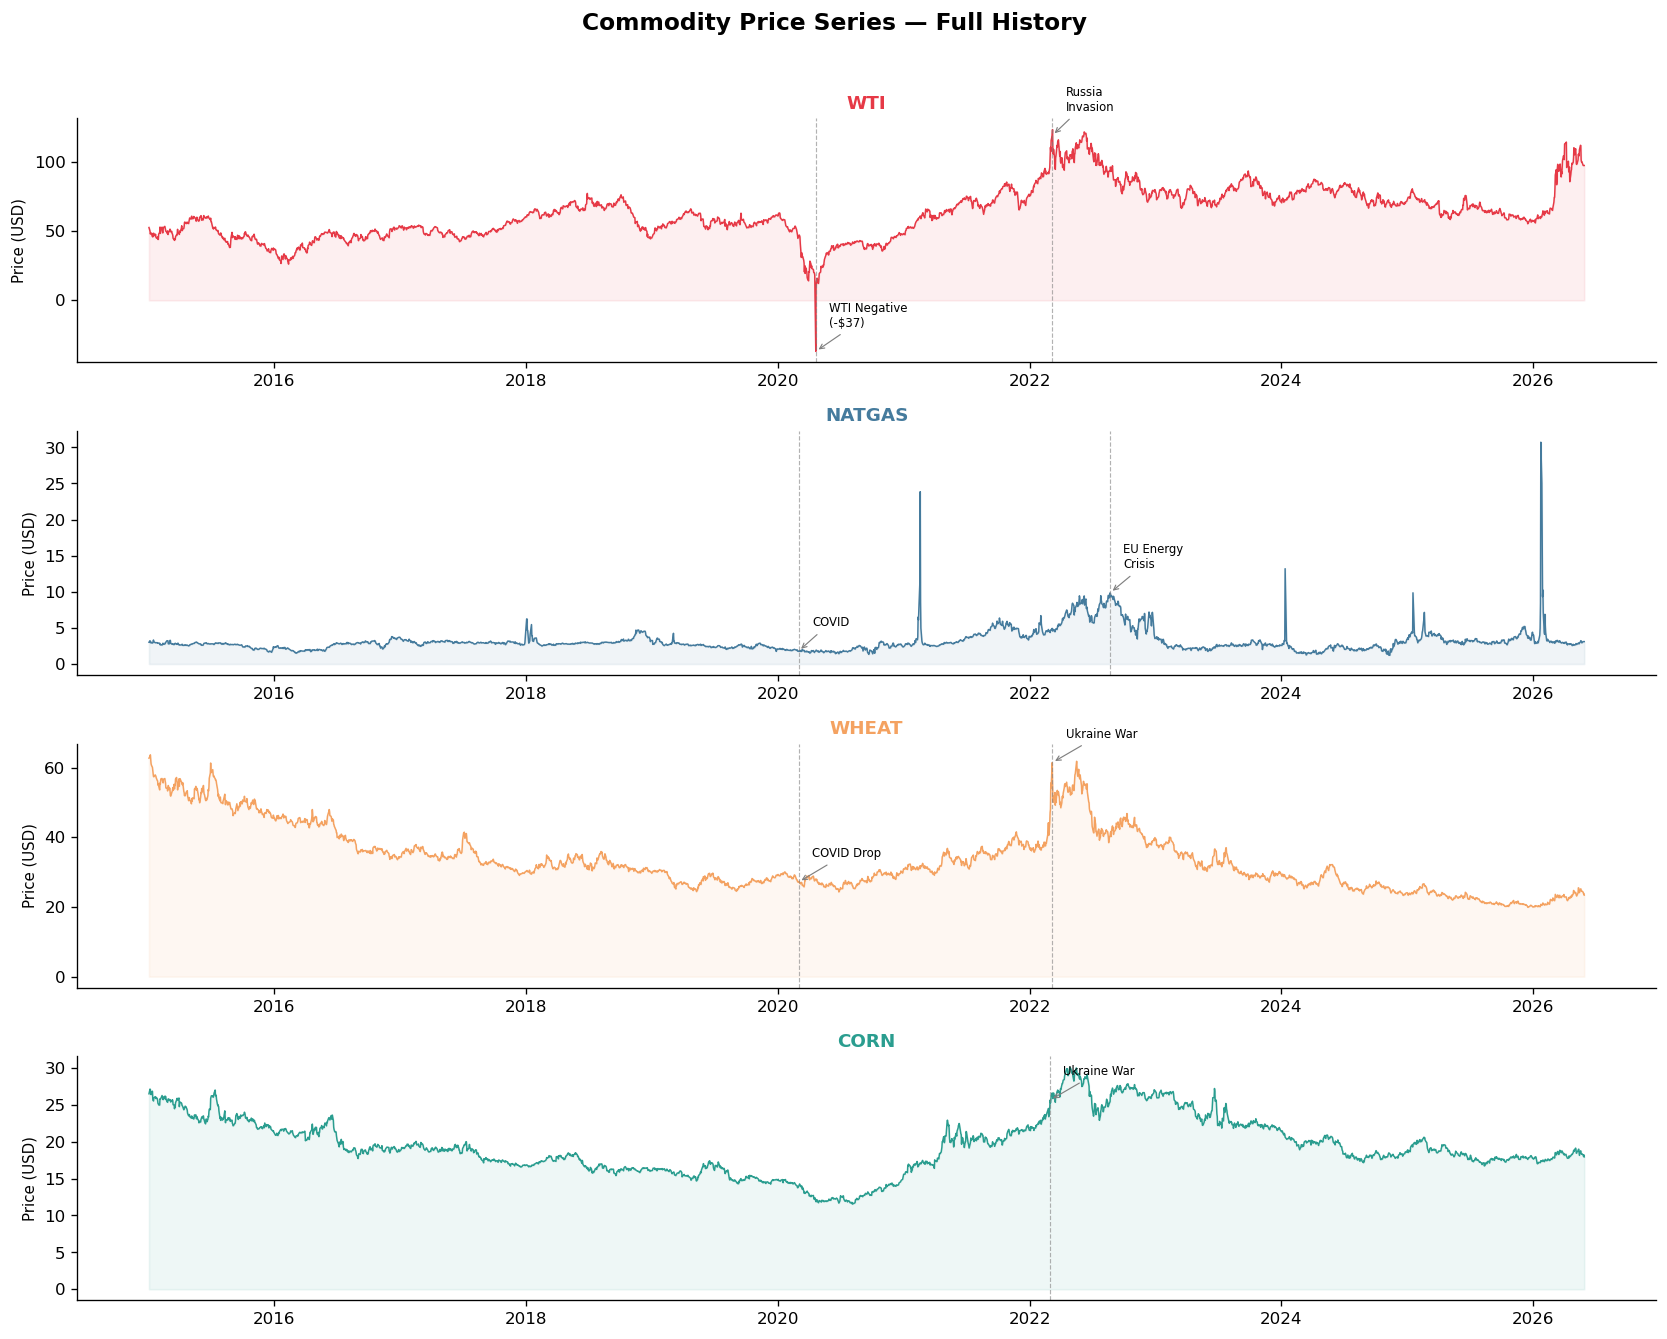

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=False)
fig.suptitle("Commodity Price Series — Full History", fontsize=14, fontweight="bold", y=1.01)

EVENTS = {
    "wti":    [("2020-04-20", "WTI Negative\n(-$37)"), ("2022-03-07", "Russia\nInvasion")],
    "natgas": [("2022-08-22", "EU Energy\nCrisis"), ("2020-03-01", "COVID")],
    "wheat":  [("2022-03-07", "Ukraine War"), ("2020-03-01", "COVID Drop")],
    "corn":   [("2022-03-01", "Ukraine War"), ("2012-08-01", "US Drought")],
}

for ax, name in zip(axes, COMMODITIES):
    df = load(name)
    close = df["close"]
    ax.plot(close.index, close, color=COLORS[name], linewidth=0.9, label=name.upper())
    ax.fill_between(close.index, close, alpha=0.08, color=COLORS[name])
    ax.set_ylabel("Price (USD)", fontsize=9)
    ax.set_title(name.upper(), fontsize=11, fontweight="bold", color=COLORS[name])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    
    for date_str, label in EVENTS.get(name, []):
        dt = pd.Timestamp(date_str)
        if close.index[0] <= dt <= close.index[-1]:
            price_at = close.asof(dt)
            ax.axvline(dt, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)
            ax.annotate(label, xy=(dt, price_at), xytext=(8, 15),
                        textcoords="offset points", fontsize=7,
                        arrowprops=dict(arrowstyle="->", color="gray", lw=0.7))

plt.tight_layout()
plt.savefig(PLOTS / "price_series.png", bbox_inches="tight")
plt.show()


---
## Q3 — Return Distributions: Are the Tails Fat?

**Why this matters for your model choice:**

Normal distribution assumes large moves are extremely rare. Financial returns have **fat tails** — extreme moves happen far more often than normal predicts. This is why plain linear models fail on financial data.

**Excess kurtosis** measures how fat the tails are:
- Normal distribution = 0
- Financial returns typically = 3–15 (sometimes much higher)
- High kurtosis → GARCH is the right baseline (it was invented for this)

**The QQ plot** is the visual test: if points fall on the diagonal, the distribution is normal. An S-curve means fat tails.

**Skewness** tells you if losses or gains dominate the extreme tail:
- Negative skew = left tail heavier = large losses more common than large gains
- Energy commodities typically show negative skew


/home/brenda/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


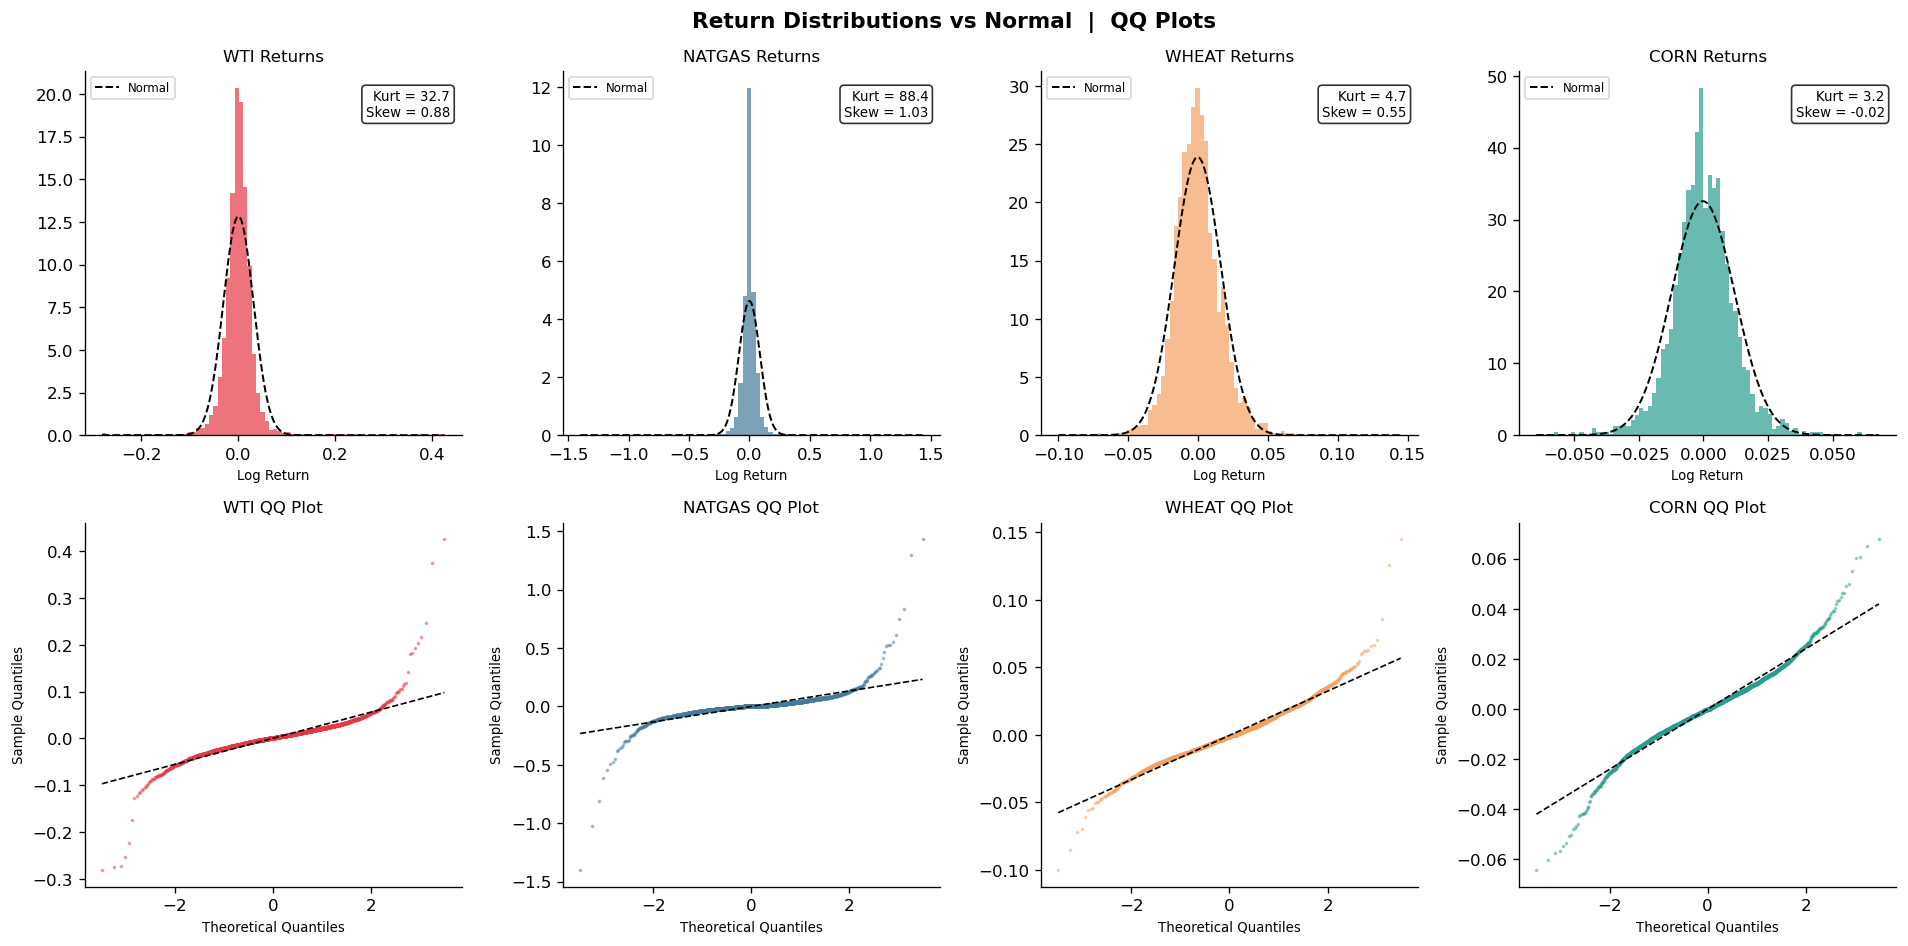

,Ann. Mean Return,Ann. Volatility,Excess Kurtosis,Skewness,JB p-value,Fat tails?
Commodity,,,,,,
WTI,11.75%,49.38%,32.66,0.88,0.00e+00,✓ Yes
NATGAS,0.26%,136.79%,88.43,1.03,0.00e+00,✓ Yes
WHEAT,-8.67%,26.50%,4.69,0.55,0.00e+00,✓ Yes
CORN,-3.43%,19.46%,3.18,-0.02,6.17e-264,✓ Yes


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Return Distributions vs Normal  |  QQ Plots", fontsize=13, fontweight="bold")

stats_rows = []

for i, name in enumerate(COMMODITIES):
    df = load(name)
    ret = log_returns(df["close"])
    
    kurt   = stats.kurtosis(ret)
    skew   = stats.skew(ret)
    _, jb_p = stats.jarque_bera(ret)
    
    stats_rows.append({
        "Commodity"         : name.upper(),
        "Ann. Mean Return"  : f"{ret.mean()*252:.2%}",
        "Ann. Volatility"   : f"{ret.std()*np.sqrt(252):.2%}",
        "Excess Kurtosis"   : round(kurt, 2),
        "Skewness"          : round(skew, 2),
        "JB p-value"        : f"{jb_p:.2e}",
        "Fat tails?"        : "✓ Yes" if kurt > 3 else "⚠ Check data",
    })
    
    # Histogram + normal overlay
    ax = axes[0, i]
    ax.hist(ret, bins=80, color=COLORS[name], alpha=0.7, density=True)
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), "k--", lw=1.2, label="Normal")
    ax.set_title(f"{name.upper()} Returns", fontsize=10)
    ax.set_xlabel("Log Return", fontsize=8)
    ax.legend(fontsize=7)
    ax.annotate(f"Kurt = {kurt:.1f}\nSkew = {skew:.2f}",
                xy=(0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=8,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # QQ plot
    ax2 = axes[1, i]
    (osm, osr), (slope, intercept, r) = stats.probplot(ret, dist="norm")
    ax2.scatter(osm, osr, s=1.5, alpha=0.4, color=COLORS[name])
    ax2.plot(osm, slope*np.array(osm)+intercept, "k--", lw=1)
    ax2.set_title(f"{name.upper()} QQ Plot", fontsize=10)
    ax2.set_xlabel("Theoretical Quantiles", fontsize=8)
    ax2.set_ylabel("Sample Quantiles", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS / "return_distributions.png", bbox_inches="tight")
plt.show()

pd.DataFrame(stats_rows).set_index("Commodity")


**How to read these results:**

- **Kurtosis > 3** → fat tails confirmed → GARCH is the right tool for Week 3
- **QQ plot S-curve** → same conclusion visually
- **JB p-value < 0.05** → returns are NOT normally distributed → don't use models that assume normality (OLS, basic linear regression)
- **Negative skew** on energy commodities → bad news causes bigger moves than good news → justifies EGARCH over plain GARCH in Week 3


---
## Q4 — Volatility Clustering

**The core assumption behind GARCH:**

Volatility is not random — calm periods cluster together and turbulent periods cluster together. If you look at any commodity during COVID (March 2020), you'll see weeks of extreme daily swings. That's clustering.

**How to confirm it:**
1. Visually: the realized volatility chart should show clear spikes that persist, not random noise
2. Statistically: squared returns should have positive autocorrelation (today's large move predicts tomorrow's large move)

If clustering is weak, GARCH adds little value over a simple rolling average.


/home/brenda/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


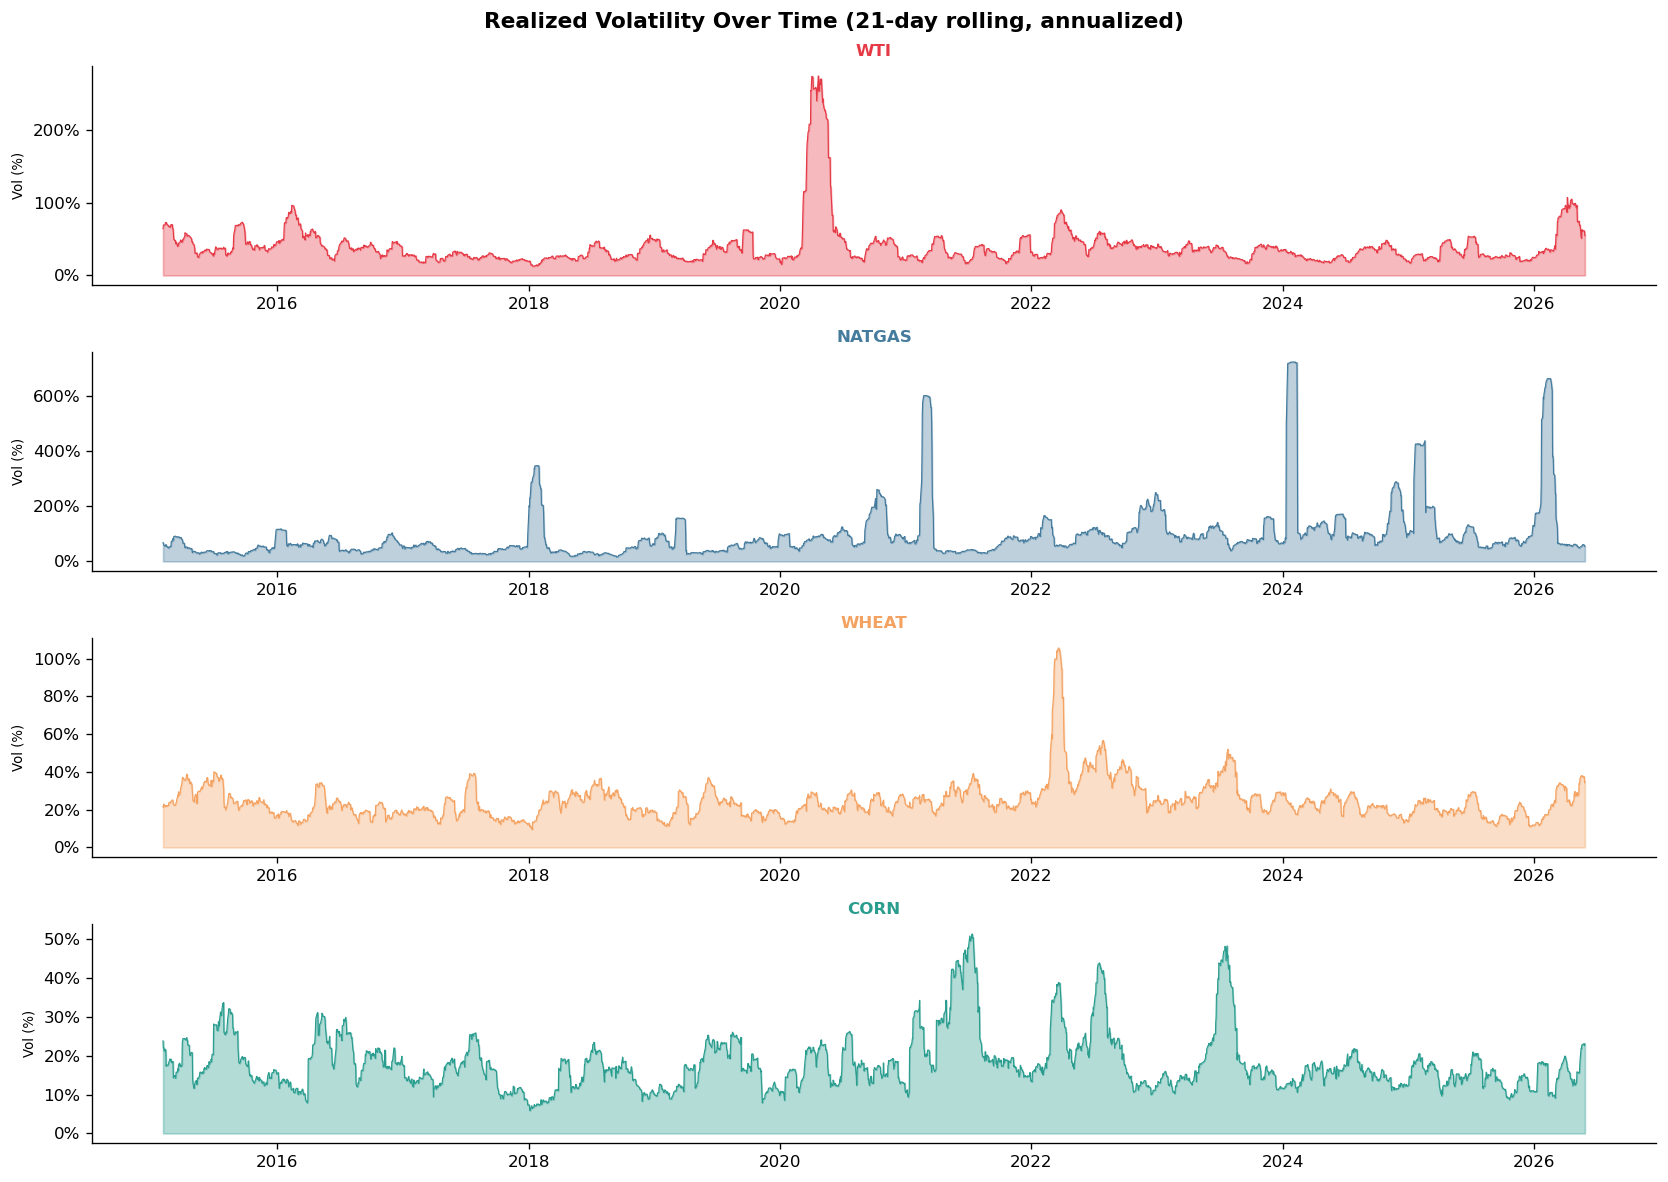

,Mean Ann. Vol,Max Ann. Vol,Sq. Return ACF lag-1,Sq. Return ACF lag-5,Clustering?
Commodity,,,,,
WTI,39.4%,274.9%,0.190,0.183,✓ Yes
NATGAS,94.8%,722.3%,0.443,0.034,✓ Yes
WHEAT,24.6%,105.6%,0.272,0.221,✓ Yes
CORN,18.0%,51.4%,0.120,0.149,✓ Yes


In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle("Realized Volatility Over Time (21-day rolling, annualized)", fontsize=13, fontweight="bold")

cluster_rows = []

for ax, name in zip(axes, COMMODITIES):
    df = load(name)
    ret = log_returns(df["close"])
    rv = realized_vol(ret, 21)
    
    ax.fill_between(rv.index, rv * 100, alpha=0.35, color=COLORS[name])
    ax.plot(rv.index, rv * 100, linewidth=0.7, color=COLORS[name])
    ax.set_ylabel("Vol (%)", fontsize=8)
    ax.set_title(name.upper(), fontsize=10, fontweight="bold", color=COLORS[name])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    
    # Key stats
    sq_ret = ret**2
    acf1 = sq_ret.autocorr(1)
    acf5 = sq_ret.autocorr(5)
    
    cluster_rows.append({
        "Commodity"             : name.upper(),
        "Mean Ann. Vol"         : f"{rv.mean()*100:.1f}%",
        "Max Ann. Vol"          : f"{rv.max()*100:.1f}%",
        "Sq. Return ACF lag-1"  : round(acf1, 3),
        "Sq. Return ACF lag-5"  : round(acf5, 3),
        "Clustering?"           : "✓ Yes" if acf1 > 0.05 else "⚠ Weak",
    })

plt.tight_layout()
plt.savefig(PLOTS / "volatility_clustering.png", bbox_inches="tight")
plt.show()

pd.DataFrame(cluster_rows).set_index("Commodity")


---
## Q5 — Stationarity

**What stationarity means:** A time series is stationary if its mean and variance don't drift over time.

- **Price levels** are NOT stationary — WTI at \$20 in 2002 vs \$120 in 2022 is the same series, but the level drifted massively.
- **Log returns** SHOULD be stationary — the percentage move on any given day has similar properties regardless of the price level.

**Why it matters:** Most models, including GARCH and LightGBM, implicitly assume stationarity. If returns aren't stationary, your model learns patterns that won't hold in the future.

**ADF Test:**
- H₀ (null): the series is non-stationary (has a unit root)
- **p < 0.05 → reject H₀ → series is stationary ✓**
- p > 0.05 → series may be non-stationary ⚠


In [11]:
from statsmodels.tsa.stattools import adfuller

adf_rows = []

for name in COMMODITIES:
    df = load(name)
    close = df["close"]
    ret = log_returns(close)
    
    adf_price = adfuller(close.dropna(), autolag="AIC")
    adf_ret   = adfuller(ret.dropna(),   autolag="AIC")
    
    adf_rows.append({
        "Commodity"         : name.upper(),
        "Price ADF p"       : round(adf_price[1], 4),
        "Price Stationary?" : "⚠ No (expected)" if adf_price[1] >= 0.05 else "Yes",
        "Return ADF p"      : round(adf_ret[1], 6),
        "Return Stationary?": "✓ Yes" if adf_ret[1] < 0.05 else "⚠ NO — INVESTIGATE",
    })

pd.DataFrame(adf_rows).set_index("Commodity")


/home/brenda/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Price ADF p,Price Stationary?,Return ADF p,Return Stationary?
Commodity,,,,
WTI,0.1912,⚠ No (expected),0.0,✓ Yes
NATGAS,0.0001,Yes,0.0,✓ Yes
WHEAT,0.1189,⚠ No (expected),0.0,✓ Yes
CORN,0.2128,⚠ No (expected),0.0,✓ Yes


**Expected result:** Prices non-stationary (p > 0.05), returns stationary (p < 0.05).

If any return series fails the stationarity test, **do not proceed to GARCH** — investigate first. Possible causes: structural break in the data, data quality issue, or very short history.


---
## Q6 — Cross-Commodity Correlations

**Why this matters for feature engineering:**

WTI crude oil and natural gas are both energy commodities. When oil spikes, gas often follows. If their **volatility** is also correlated, adding WTI's RV as a feature to the natural gas model gives the model information it can't learn from natgas alone.

**Return correlation** = do prices move together on the same day?
**Volatility correlation** = do they enter high-volatility regimes together?

Volatility correlation is what matters most for our cross-commodity features.


/home/brenda/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


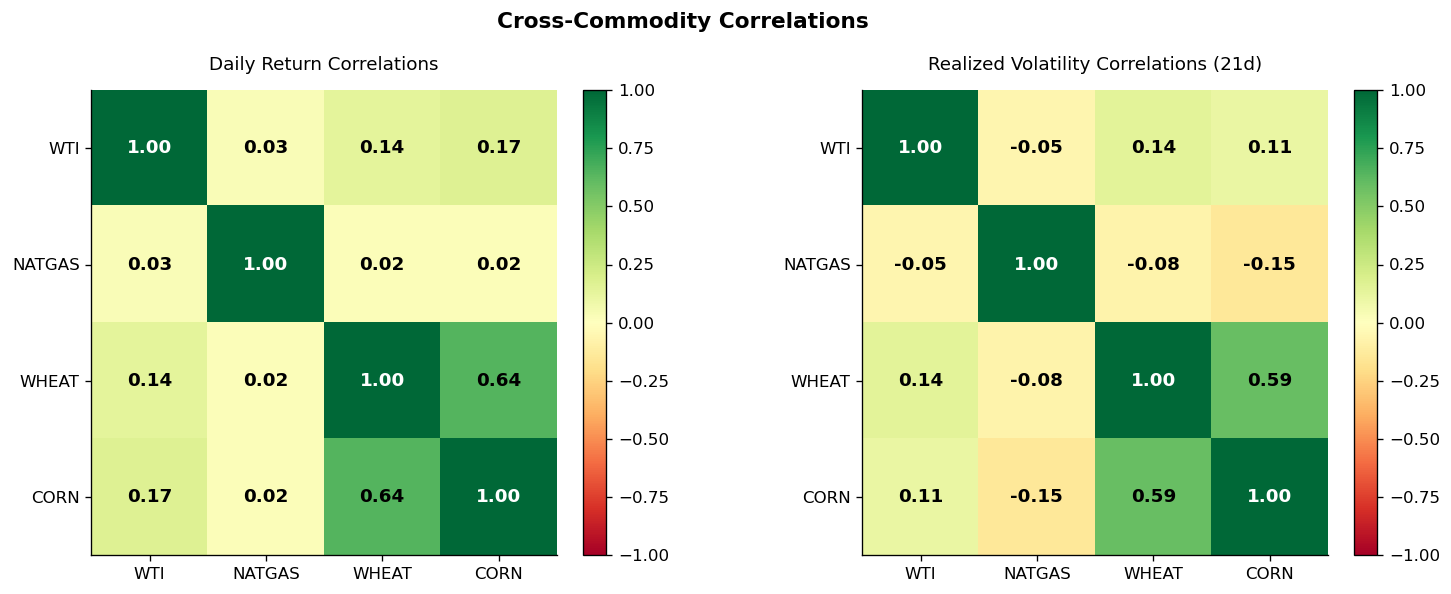

In [12]:
all_returns = {}
all_rv = {}

for name in COMMODITIES:
    df = load(name)
    ret = log_returns(df["close"])
    all_returns[name] = ret
    all_rv[name] = realized_vol(ret, 21)

returns_df = pd.DataFrame(all_returns).dropna()
rv_df = pd.DataFrame(all_rv).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Cross-Commodity Correlations", fontsize=13, fontweight="bold")

cmap = plt.cm.RdYlGn

for ax, corr_df, title in [
    (axes[0], returns_df.corr(), "Daily Return Correlations"),
    (axes[1], rv_df.corr(),      "Realized Volatility Correlations (21d)"),
]:
    im = ax.imshow(corr_df.values, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(COMMODITIES)))
    ax.set_yticks(range(len(COMMODITIES)))
    labels = [c.upper() for c in COMMODITIES]
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(title, fontsize=11, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(COMMODITIES)):
        for j in range(len(COMMODITIES)):
            ax.text(j, i, f"{corr_df.values[i,j]:.2f}",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="black" if abs(corr_df.values[i,j]) < 0.7 else "white")

plt.tight_layout()
plt.savefig(PLOTS / "correlations.png", bbox_inches="tight")
plt.show()


**Decision rule:**
- WTI–NatGas **vol correlation > 0.35** → cross-commodity feature is justified ✓
- Any pair **vol correlation > 0.6** → consider whether they're too correlated (risk of multicollinearity in LightGBM, though tree models handle it better than linear models)


---
## Q7 — Macro Variables vs Commodity Volatility

**DXY (US Dollar Index):**
Commodities are priced in USD. When the dollar strengthens sharply, commodity prices tend to fall — and the transition often accompanies volatility. A large DXY move signals a macro regime shift.

**10-Year Treasury Yield:**
The benchmark risk-free rate. When yields spike (e.g. Fed rate hike expectations), capital flows away from risk assets including commodities. Rapid yield changes signal regime transitions.

We're checking if large macro moves *coincide* with high commodity volatility — if yes, these features add signal.


In [13]:
macro_path = SILVER / "macro_daily.csv"

if macro_path.exists():
    macro = pd.read_csv(macro_path, index_col=0, parse_dates=True)
    macro.columns = macro.columns.str.lower()
    print("Macro columns found:", list(macro.columns))
    display(macro.describe().round(3))
    
    # Visual: DXY and WTI volatility on same chart
    df_wti = load("wti")
    ret_wti = log_returns(df_wti["close"])
    rv_wti = realized_vol(ret_wti, 21)
    
    if "dxy" in macro.columns:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
        fig.suptitle("DXY vs WTI Realized Volatility", fontsize=12)
        
        aligned = pd.DataFrame({"rv": rv_wti}).join(macro[["dxy"]], how="inner").dropna()
        
        ax1.plot(aligned.index, aligned["dxy"], color="#6c757d", lw=0.9)
        ax1.set_ylabel("DXY Level", fontsize=9)
        ax1.set_title("US Dollar Index (DXY)", fontsize=10)
        
        ax2.fill_between(aligned.index, aligned["rv"]*100, alpha=0.4, color=COLORS["wti"])
        ax2.plot(aligned.index, aligned["rv"]*100, color=COLORS["wti"], lw=0.8)
        ax2.set_ylabel("WTI Vol (%)", fontsize=9)
        ax2.set_title("WTI Realized Volatility (21d)", fontsize=10)
        
        plt.tight_layout()
        plt.savefig(PLOTS / "macro_vs_vol.png", bbox_inches="tight")
        plt.show()
        
        # Correlation table
        macro_corr_rows = []
        for name in ["wti", "natgas"]:
            df_c = load(name)
            ret = log_returns(df_c["close"])
            rv = realized_vol(ret, 21)
            aligned = pd.DataFrame({"rv": rv}).join(macro, how="inner").dropna()
            
            row = {"Commodity": name.upper()}
            if "dxy" in aligned.columns:
                dxy_chg = np.log(aligned["dxy"] / aligned["dxy"].shift(1)).abs()
                row["|DXY change| vs RV corr"] = round(aligned["rv"].corr(dxy_chg), 3)
            if "treasury_10y" in aligned.columns:
                yld_chg = aligned["treasury_10y"].diff().abs()
                row["|Yield change| vs RV corr"] = round(aligned["rv"].corr(yld_chg), 3)
            macro_corr_rows.append(row)
        
        display(pd.DataFrame(macro_corr_rows).set_index("Commodity"))
else:
    print("⚠ macro_daily.csv not found at", macro_path)
    print("Expected columns: dxy, treasury_10y")
    print("If your FRED ingest used different column names, update the code above.")


⚠ macro_daily.csv not found at ../data/silver/macro_daily.csv
Expected columns: dxy, treasury_10y
If your FRED ingest used different column names, update the code above.


---
## Q8 — Data Quality Red Flags

Specific checks for known problems in each data source:

- **EIA (WTI, NatGas):** Known negative WTI price on 2020-04-20. Contract roll artifacts.
- **yfinance (WEAT, CORN ETFs):** ETF distributions can create artificial price drops. Volume can be zero on illiquid days.
- **FRED (DXY, Treasury):** Occasional data revisions. Missing values on US public holidays.

For each extreme return, you need to consciously decide: **keep it, drop it, or clip it.** Document your decision.


In [14]:
print("Extreme return dates (|return| > 10%) — verify each one is a real market event:\n")

for name in COMMODITIES:
    df = load(name)
    ret = log_returns(df["close"])
    extreme = ret[ret.abs() > 0.10].sort_values(key=abs, ascending=False)
    
    print(f"{'─'*55}")
    print(f"  {name.upper()} — {len(extreme)} extreme moves")
    if len(extreme) > 0:
        display(
            extreme.rename("log_return")
            .to_frame()
            .assign(pct_move=lambda d: d["log_return"].map(lambda x: f"{x:.1%}"))
            [["pct_move"]]
            .head(10)
        )


Extreme return dates (|return| > 10%) — verify each one is a real market event:

───────────────────────────────────────────────────────
  WTI — 29 extreme moves


/home/brenda/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,pct_move
date,
2020-04-22,42.6%
2020-03-31,37.5%
2020-03-09,-28.1%
2020-03-18,-27.5%
2020-04-27,-27.3%
2020-03-20,-25.3%
2020-04-30,24.6%
2020-03-26,-22.3%
2020-04-02,21.6%


───────────────────────────────────────────────────────
  NATGAS — 203 extreme moves


,pct_move
date,
2024-01-12,143.3%
2024-01-16,-140.2%
2026-01-23,129.4%
2021-02-18,-102.5%
2025-01-17,83.0%
2025-01-21,-80.7%
2021-02-17,74.6%
2021-02-16,61.5%
2026-01-28,-61.0%


───────────────────────────────────────────────────────
  WHEAT — 3 extreme moves


,pct_move
date,
2022-03-03,14.5%
2022-03-07,12.6%
2022-03-08,-10.0%


───────────────────────────────────────────────────────
  CORN — 0 extreme moves


In [15]:
# Zero-volume days (yfinance data only)
print("Zero-volume days (yfinance ETF data):")
for name in ["wheat", "corn"]:
    df = load(name)
    if "volume" in df.columns:
        zero_vol = df[df["volume"] == 0]
        print(f"  {name.upper()}: {len(zero_vol)} zero-volume days")
        if len(zero_vol) > 0:
            print(zero_vol[["close", "volume"]].head())
    else:
        print(f"  {name.upper()}: no volume column in data")


Zero-volume days (yfinance ETF data):
  WHEAT: 0 zero-volume days
  CORN: 0 zero-volume days


---
## EDA Summary & Decisions Before Feature Engineering

Fill this in after running all cells above.

| Question | Finding | Decision |
|----------|---------|----------|
| Negative WTI price? | _2020-04-20: -$37.63_ | _Drop that row / clip return_ |
| Fat tails confirmed? | _Kurtosis: WTI=?, NatGas=?, Wheat=?, Corn=?_ | _GARCH justified ✓_ |
| Volatility clustering? | _ACF lag-1: WTI=?, NatGas=?_ | _GARCH appropriate ✓_ |
| Returns stationary? | _ADF p-values: all < 0.05?_ | _Proceed / Investigate_ |
| WTI–NatGas vol corr? | _r = ?_ | _Cross-commodity feature: Yes/No_ |
| Missing OHLC? | _EIA gives OHLC? Yes/No_ | _Garman-Klass + ATR: Yes/Skip_ |
| Macro signal? | _DXY–WTI corr = ?_ | _Include macro features ✓_ |
| Data quality flags? | _List any extreme dates_ | _Keep/Drop decisions_ |

**Once this table is filled, you're ready to run `features.py`.**
